# Association

**Association** measures the relationship between two categorical variables.

We'll use a heatmap to feel the difference.

In [1]:
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## Example 1: Titanic Survival and Class

**Question**:

- People in higher `pclass` on the titanic may have had access to life boats or may have been simply treated better.
- Is there an association between that and whether they `survived` or not?

Let's find out..

In [2]:
titanic = sns.load_dataset('titanic')
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


### Contingency Table

A **Contingency Table** displays the joint frequency of two or more categorical variables as follows:

- Categories: One variable is assigned to the rows, and the other is assigned to the columns.
- Cells: The intersections containing the frequency (the exact count) of data points that match both the row and column categories.

In [3]:
table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
)
table

survived,0,1
pclass,,
1,80,136
2,97,87
3,372,119


Let's try three variables for the sake of understanding how it is displayed:

In [4]:
table = pd.crosstab(
    index=[titanic['pclass'],
    titanic['sex']],
    columns=titanic['survived']
)
table

survived         0   1
pclass sex            
1      female    3  91
       male     77  45
2      female    6  70
       male     91  17
3      female   72  72
       male    300  47

Let's look at it's index:

In [5]:
table.index

MultiIndex([(1, 'female'),
            (1,   'male'),
            (2, 'female'),
            (2,   'male'),
            (3, 'female'),
            (3,   'male')],
           names=['pclass', 'sex'])

The index tells us that we can reach a specific value as follows:

In [6]:
print(table.loc[(2, 'male'), 0])

91


### Relative Frequency

We are interested in the frequency distribution of the target `survived` per `pclass`:

In [7]:
contingency_table = pd.crosstab(
    index=titanic['pclass'],
    columns=titanic['survived'],
    
    normalize='index' # Added
)
contingency_table

survived,0,1
pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Using a `heatmap` to add color and intensity makes it easier to read and compare:

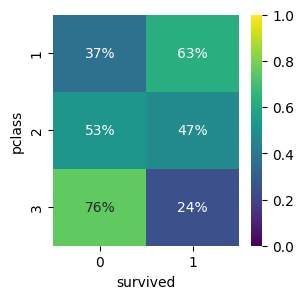

In [8]:
plt.figure(figsize=(3, 3))
sns.heatmap(
    contingency_table,
    annot=True, cmap="viridis", fmt=".0%", vmin=0, vmax=1
);

In the heatmap above, do you observe a relationship between the two variables?

## Example 2: Sex and Occupation

In this example, we'll use the [Adult Dataset from UCI](https://archive.ics.uci.edu/dataset/2/adult).

**Question**: are there gender differences between preferences of occupations?

In [9]:
data_path = Path('./data/adult.csv')
adult = pd.read_csv(data_path)
adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [10]:
# Create a dictionary mapping the original labels to the meaningful names
occupation_mapping = {
    'Tech-support': 'Technical Support',
    'Craft-repair': 'Skilled Trades & Repair',
    'Other-service': 'General Service',
    'Exec-managerial': 'Executive & Managerial',
    'Prof-specialty': 'Professional Specialty',
    'Handlers-cleaners': 'Handlers & Cleaners',
    'Machine-op-inspct': 'Machine Operators & Inspectors',
    'Adm-clerical': 'Administrative & Clerical',
    'Farming-fishing': 'Farming & Fishing',
    'Transport-moving': 'Transportation & Moving',
    'Priv-house-serv': 'Private Household Services',
    'Protective-serv': 'Protective Services',
    'Armed-Forces': 'Armed Forces'
}

# Apply the replacement directly to the occupation column
adult['occupation'] = adult['occupation'].replace(occupation_mapping)

Create a contingency table to analyze the association between `sex` and `occupation`:

In [11]:
adult_contingency_table = pd.crosstab(
    index=adult['occupation'],
    columns=adult['sex'],
    normalize='index'
)
adult_contingency_table

sex,Female,Male
occupation,,
Administrative & Clerical,0.672944,0.327056
Armed Forces,0.000000,1.000000
Executive & Managerial,0.285047,0.714953
Farming & Fishing,0.065392,0.934608
General Service,0.546282,0.453718
Handlers & Cleaners,0.119708,0.880292
Machine Operators & Inspectors,0.274725,0.725275
Private Household Services,0.946309,0.053691
Professional Specialty,0.365942,0.634058


Using a `heatmap` to add color and intensity makes it easier to read and compare:

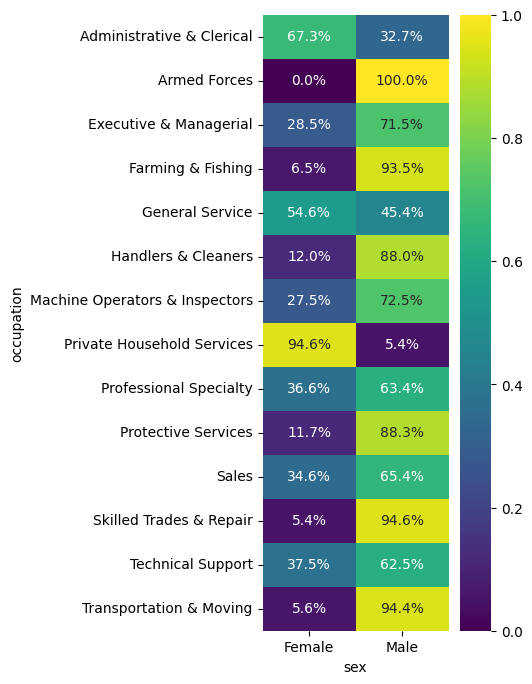

In [12]:
plt.figure(figsize=(3, 8))
sns.heatmap(
    adult_contingency_table,
    annot=True, cmap="viridis", fmt=".1%", vmin=0, vmax=1
);

## Arabic Text

To write Arabic script to render on plots we need:

1. arrange the letters RTL (using [`python-bidi`](https://pypi.org/project/python-bidi/))
2. join and render them (using [`arabic-reshaper`](https://pypi.org/project/arabic-reshaper/))

### Setup

In [13]:
# Install it if you haven't
# !uv add arabic-reshaper python-bidi

In [14]:
import arabic_reshaper
from bidi.algorithm import get_display

def prep_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

In [50]:
adult = pd.read_csv(data_path)

### Rename Values

In [51]:
occupation_mapping = {
    'Tech-support': 'الدعم الفني',
    'Craft-repair': 'الحرف والإصلاح',
    'Other-service': 'خدمات أخرى',
    'Sales': 'المبيعات',
    'Exec-managerial': 'إدارة تنفيذية',
    'Prof-specialty': 'تخصص مهني',
    'Handlers-cleaners': 'عمال المناولة والنظافة',
    'Machine-op-inspct': 'مشغلو ومفتشو الآلات',
    'Adm-clerical': 'أعمال إدارية وكتابية',
    'Farming-fishing': 'الزراعة وصيد الأسماك',
    'Transport-moving': 'النقل والتحريك',
    'Priv-house-serv': 'خدمات منزلية خاصة',
    'Protective-serv': 'خدمات الحماية',
    'Armed-Forces': 'القوات المسلحة'
}

adult['occupation'] = adult['occupation'].replace(occupation_mapping)

In [52]:
sex_mapping = {
    'Male': 'ذكر',
    'Female': 'أنثى'
}
adult['sex'] = adult['sex'].replace(sex_mapping)

### Create Contingency Table

We'll also make sure all text subject to rendering (being displayed) is preprocessed:

In [53]:
adult_contingency_table = pd.crosstab(
    index=adult['occupation'],
    columns=adult['sex'],
    normalize='index'
)

# apply the text fix to all labels
fixed_index = [prep_arabic(label) for label in adult_contingency_table.index]
fixed_columns = [prep_arabic(label) for label in adult_contingency_table.columns]

We'll use the font_manager from matplotlib to lookup the available fonts, to select an Arabic font:

In [54]:
import matplotlib.font_manager as fm

font_list = fm.get_font_names()

# Look for Arabic fonts within
# for font in font_list:
#     print(font)

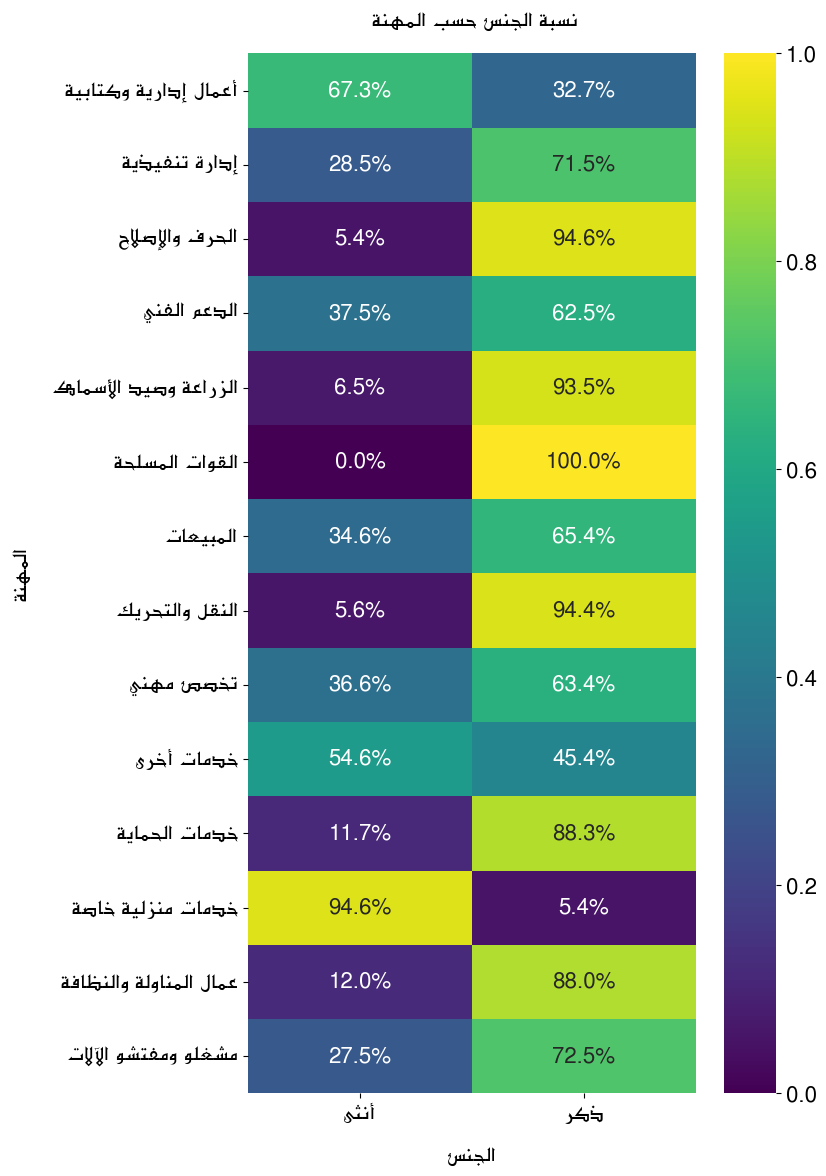

In [55]:
# Select font
plt.rcParams['font.family'] = 'AlBattar'
plt.rcParams['font.size'] = 16

# Plot the figure
plt.figure(figsize=(8, 16))
sns.heatmap(
    adult_contingency_table,
    xticklabels=fixed_columns, 
    yticklabels=fixed_index,
    annot=True, cmap="viridis", fmt=".1%", vmin=0, vmax=1
)

# Apply fixes to titles and axis labels
plt.title(prep_arabic('نسبة الجنس حسب المهنة '), fontsize=16, pad=20)
plt.ylabel(prep_arabic('المهنة'), labelpad=15)
plt.xlabel(prep_arabic('الجنس'), labelpad=15)

# allocate margin space instead
plt.subplots_adjust(bottom=0.25, left=0.25, right=0.95, top=0.90)

plt.show()

## Other Plots for Comparison

### Adjacent Bars

/tmp/ipykernel_135103/3644083319.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(fixed_yticks)


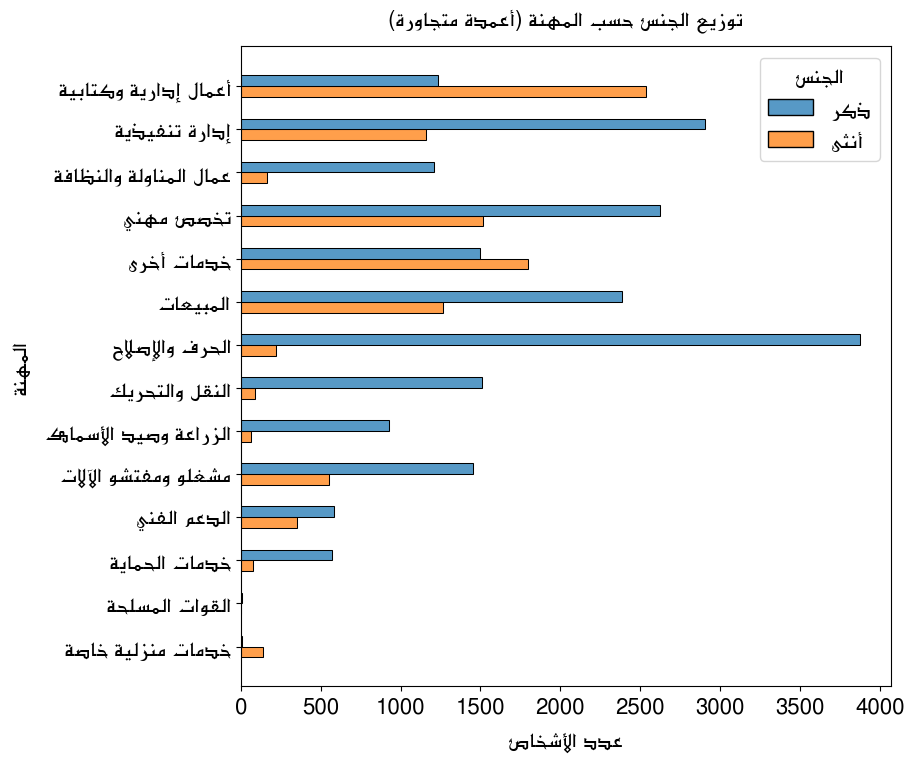

In [57]:
plt.rcParams['font.family'] = 'AlBattar'
plt.rcParams['font.size'] = 16
plt.figure(figsize=(10, 8))


ax = sns.histplot(
    adult,
    y='occupation', hue='sex',
    discrete=True, shrink=0.5,
    multiple='dodge', # Adjacent bars
)

current_yticks = ax.get_yticklabels()
fixed_yticks = [prep_arabic(label.get_text()) for label in current_yticks]
ax.set_yticklabels(fixed_yticks)

# Fix the Legend dynamically
# Seaborn auto-generates the legend from the 'hue' column
if ax.get_legend() is not None:
    legend = ax.get_legend()
    legend.set_title(prep_arabic('الجنس')) # Translate the legend title
    for text in legend.get_texts():
        text.set_text(prep_arabic(text.get_text())) # Fix 'Male' / 'Female'

# Titles and axis labels
plt.title(prep_arabic('توزيع الجنس حسب المهنة (أعمدة متجاورة)'), fontsize=16, pad=15)
plt.ylabel(prep_arabic('المهنة'), labelpad=10)
plt.xlabel(prep_arabic('عدد الأشخاص'), labelpad=10)

# Fix the RTL squishing bug by defining hard margins
plt.subplots_adjust(left=0.30, right=0.95, top=0.90, bottom=0.10)

### Stacked Bars

/tmp/ipykernel_135103/2317222555.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(fixed_yticks)


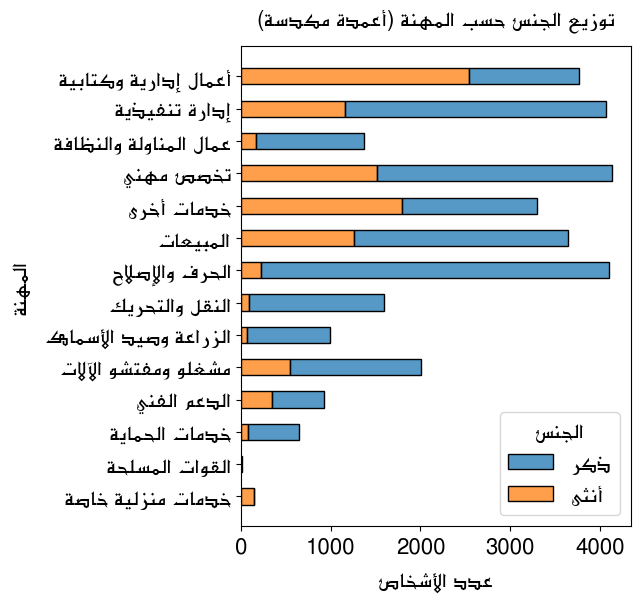

In [59]:
plt.rcParams['font.family'] = 'AlBattar'
plt.rcParams['font.size'] = 16
plt.figure(figsize=(6, 6))

ax = sns.histplot(
    adult,
    y='occupation', hue='sex',
    discrete=True, shrink=0.5,
    multiple='stack', # Stacked bars
)

current_yticks = ax.get_yticklabels()
fixed_yticks = [prep_arabic(label.get_text()) for label in current_yticks]
ax.set_yticklabels(fixed_yticks)

# Fix the Legend dynamically
if ax.get_legend() is not None:
    legend = ax.get_legend()
    legend.set_title(prep_arabic('الجنس')) # Translate the legend title
    for text in legend.get_texts():
        text.set_text(prep_arabic(text.get_text())) # Fix 'Male' / 'Female'

plt.title(prep_arabic('توزيع الجنس حسب المهنة (أعمدة مكدسة)'), fontsize=16, pad=15)
plt.ylabel(prep_arabic('المهنة'), labelpad=10)
plt.xlabel(prep_arabic('عدد الأشخاص'), labelpad=10)

plt.subplots_adjust(left=0.30, right=0.95, top=0.90, bottom=0.10)

### Complementary bars

/tmp/ipykernel_135103/1153604813.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(fixed_yticks)


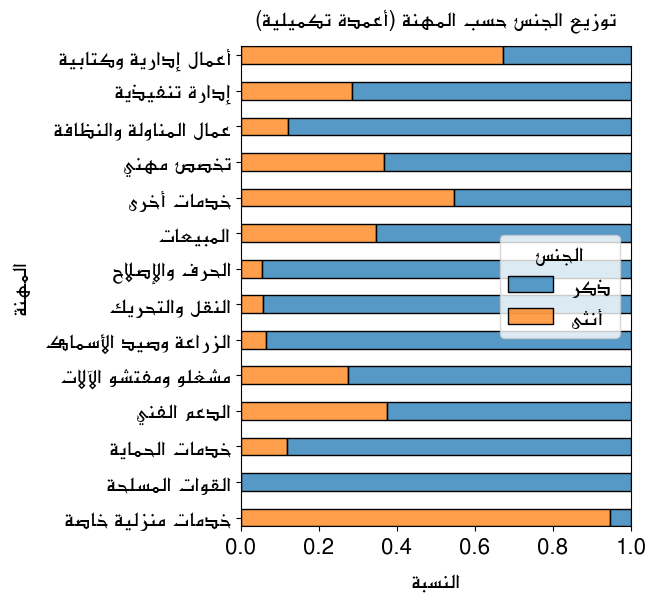

In [60]:
plt.rcParams['font.family'] = 'AlBattar'
plt.rcParams['font.size'] = 16
plt.figure(figsize=(6, 6))

ax = sns.histplot(
    adult,
    y='occupation', hue='sex',
    discrete=True, shrink=0.5,
    multiple='fill', # Complementary bars
)

current_yticks = ax.get_yticklabels()
fixed_yticks = [prep_arabic(label.get_text()) for label in current_yticks]
ax.set_yticklabels(fixed_yticks)

# Fix the Legend dynamically
if ax.get_legend() is not None:
    legend = ax.get_legend()
    legend.set_title(prep_arabic('الجنس')) # Translate the legend title
    for text in legend.get_texts():
        text.set_text(prep_arabic(text.get_text())) # Fix 'Male' / 'Female'

plt.title(prep_arabic('توزيع الجنس حسب المهنة (أعمدة تكميلية)'), fontsize=16, pad=15)
plt.ylabel(prep_arabic('المهنة'), labelpad=10)
plt.xlabel(prep_arabic('النسبة'), labelpad=10)

plt.subplots_adjust(left=0.30, right=0.95, top=0.90, bottom=0.10)